In [4]:
import geopandas as gpd
import pandas as pd
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import cohen_kappa_score

In [6]:
Mont_shp = gpd.read_file(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MontecitoBasins_Prob.shp')
Mont_shp.columns


Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_', 'area',
       'Field', 'ROC', 'nearest_st', 'distance_t', 'RI_index', 'RI',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'M1P_Mean', 'M1P_Med', 'M1p_PF',
       'M1M_dNBR', 'M1Md_dNBR', 'M1PF_dNBR', 'M1Q1_dNBR', 'HM1M_dNBR',
       'HM1Md_dNBR', 'HM1PF_dNBR', 'HM1Q1_dNBR', 'OHM1M_dNBR', 'OHM1Md_dNB',
       'OHM1PF_dNB', 'OHM1Q1_dNB', 'M1M_prob', 'M1Md_prob', 'M1PF_prob',
       'M1Q1_prob', 'HM1M_prob', 'HM1Md_prob', 'HM1PF_prob', 'HM1Q1_prob',
       'OHM1M_prob', 'OHM1Md_pro', 'OHM1PF_pro', 'OHM1Q1_pro', 'Old_ROC',
       'geometry'],
      dtype='object')

In [10]:
ROC_df = {
    'BASIN_ID': Mont_shp['BASIN_ID'],
    'AREA': Mont_shp['Shape_Area'],
    'M1P_Mean': Mont_shp['M1M_prob'],
    'M1P_Med': Mont_shp['M1Md_prob'],
    'M1P_PF': Mont_shp['M1PF_prob'],
    'QM1': Mont_shp['M1Q1_prob'],
    'HM1P_Mean': Mont_shp['HM1M_prob'],
    'HM1P_Med': Mont_shp['HM1Md_prob'],
    'HM1P_PF': Mont_shp['HM1PF_prob'],
    'QHM1': Mont_shp['HM1Q1_prob'],
    'OHM1P_Mean': Mont_shp['OHM1M_prob'],
    'OHM1P_Med': Mont_shp['OHM1Md_pro'],
    'OHM1P_PF': Mont_shp['OHM1PF_pro'],
    'QOHM1': Mont_shp['OHM1Q1_pro'],
    'RI': Mont_shp['RI'],
    'Old_ROC': Mont_shp['Old_ROC']
}
ROC_df = pd.DataFrame(ROC_df)
ROC_df

,BASIN_ID,AREA,M1P_Mean,M1P_Med,M1P_PF,QM1,HM1P_Mean,HM1P_Med,HM1P_PF,QHM1,OHM1P_Mean,OHM1P_Med,OHM1P_PF,QOHM1,RI,Old_ROC
0,12057,3.219000e+05,0.998743,0.999379,0.999738,0.988967,0.999664,0.999818,0.999915,0.995891,0.999761,0.999920,0.999913,0.995037,19.56,4
1,13281,3.442000e+05,0.910854,0.651211,0.472421,0.419910,0.955901,0.774203,0.602017,0.512938,0.951872,0.785423,0.603456,0.339187,19.56,4
2,19777,2.102000e+05,0.999584,0.999735,0.999809,0.998864,0.999862,0.999924,0.999936,0.999615,0.999886,0.999946,0.999936,0.999396,26.16,4
3,20254,1.261000e+05,0.998125,0.999110,0.999434,0.991657,0.998887,0.999524,0.999720,0.994900,0.999217,0.999752,0.999720,0.996129,18.54,4
4,20308,1.755000e+05,0.999988,0.999998,0.999999,0.999391,0.999993,0.999999,1.000000,0.999449,0.999996,1.000000,1.000000,0.999459,26.16,4
5,21634,6.950000e+04,0.993195,0.994789,0.999134,0.945763,0.993829,0.995601,0.999461,0.941958,0.993860,0.996592,0.999459,0.834334,18.54,4
6,17346,5.057100e+06,0.999881,0.999965,0.999983,0.998112,0.999955,0.999987,0.999995,0.998875,0.999956,0.999990,0.999995,0.997543,19.56,2
7,17347,3.885200e+06,0.999993,0.999995,0.999996,0.999982,0.999998,0.999999,0.999999,0.999994,0.999999,0.999999,0.999999,0.999995,19.56,2
8,17987,1.683000e+05,0.999938,0.999948,0.999954,0.999890,0.999983,0.999985,0.999985,0.999967,0.999988,0.999992,0.999985,0.999974,18.54,2
9,19165,4.431700e+06,0.999999,1.000000,1.000000,0.999995,1.000000,1.000000,1.000000,0.999997,1.000000,1.000000,1.000000,0.999995,26.16,2


In [14]:
#Ground truth category
ROC_df['DF'] = ROC_df['Old_ROC'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

#M1 ROC setup
ROC_df['M1_Mean_50'] = ROC_df['M1P_Mean'].apply(lambda x: 1 if x > 0.5 else 0)
ROC_df['HM1_Mean_50'] = ROC_df['HM1P_Mean'].apply(lambda x: 1 if x > 0.5 else 0)
ROC_df['OHM1_Mean_50'] = ROC_df['OHM1P_Mean'].apply(lambda x: 1 if x > 0.5 else 0)

ROC_df['M1_Med_50'] = ROC_df['M1P_Med'].apply(lambda x: 1 if x > 0.5 else 0)
ROC_df['HM1_Med_50'] = ROC_df['HM1P_Med'].apply(lambda x: 1 if x > 0.5 else 0)
ROC_df['OHM1_Med_50'] = ROC_df['OHM1P_Med'].apply(lambda x: 1 if x > 0.5 else 0)

ROC_df['M1_PF_50'] = ROC_df['M1P_PF'].apply(lambda x: 1 if x > 0.5 else 0)
ROC_df['HM1_PF_50'] = ROC_df['HM1P_PF'].apply(lambda x: 1 if x > 0.5 else 0)
ROC_df['OHM1_PF_50'] = ROC_df['OHM1P_PF'].apply(lambda x: 1 if x > 0.5 else 0)

ROC_df['QM1_50'] = ROC_df['QM1'].apply(lambda x: 1 if x > 0.5 else 0)
ROC_df['QHM1_50'] = ROC_df['QHM1'].apply(lambda x: 1 if x > 0.5 else 0)
ROC_df['QOHM1_50'] = ROC_df['QOHM1'].apply(lambda x: 1 if x > 0.5 else 0)

ROC_df['M1_Mean_60'] = ROC_df['M1P_Mean'].apply(lambda x: 1 if x > 0.6 else 0)
ROC_df['HM1_Mean_60'] = ROC_df['HM1P_Mean'].apply(lambda x: 1 if x > 0.6 else 0)
ROC_df['OHM1_Mean_60'] = ROC_df['OHM1P_Mean'].apply(lambda x: 1 if x > 0.6 else 0)

ROC_df['M1_Med_60'] = ROC_df['M1P_Med'].apply(lambda x: 1 if x > 0.6 else 0)
ROC_df['HM1_Med_60'] = ROC_df['HM1P_Med'].apply(lambda x: 1 if x > 0.6 else 0)
ROC_df['OHM1_Med_60'] = ROC_df['OHM1P_Med'].apply(lambda x: 1 if x > 0.6 else 0)

ROC_df['M1_PF_60'] = ROC_df['M1P_PF'].apply(lambda x: 1 if x > 0.6 else 0)
ROC_df['HM1_PF_60'] = ROC_df['HM1P_PF'].apply(lambda x: 1 if x > 0.6 else 0)
ROC_df['OHM1_PF_60'] = ROC_df['OHM1P_PF'].apply(lambda x: 1 if x > 0.6 else 0)

ROC_df['QM1_60'] = ROC_df['QM1'].apply(lambda x: 1 if x > 0.6 else 0)
ROC_df['QHM1_60'] = ROC_df['QHM1'].apply(lambda x: 1 if x > 0.6 else 0)
ROC_df['QOHM1_60'] = ROC_df['QOHM1'].apply(lambda x: 1 if x > 0.6 else 0)

ROC_df['M1_Mean_70'] = ROC_df['M1P_Mean'].apply(lambda x: 1 if x > 0.7 else 0)
ROC_df['HM1_Mean_70'] = ROC_df['HM1P_Mean'].apply(lambda x: 1 if x > 0.7 else 0)
ROC_df['OHM1_Mean_70'] = ROC_df['OHM1P_Mean'].apply(lambda x: 1 if x > 0.7 else 0)

ROC_df['M1_Med_70'] = ROC_df['M1P_Med'].apply(lambda x: 1 if x > 0.7 else 0)
ROC_df['HM1_Med_70'] = ROC_df['HM1P_Med'].apply(lambda x: 1 if x > 0.7 else 0)
ROC_df['OHM1_Med_70'] = ROC_df['OHM1P_Med'].apply(lambda x: 1 if x > 0.7 else 0)

ROC_df['M1_PF_70'] = ROC_df['M1P_PF'].apply(lambda x: 1 if x > 0.7 else 0)
ROC_df['HM1_PF_70'] = ROC_df['HM1P_PF'].apply(lambda x: 1 if x > 0.7 else 0)
ROC_df['OHM1_PF_70'] = ROC_df['OHM1P_PF'].apply(lambda x: 1 if x > 0.7 else 0)

ROC_df['QM1_70'] = ROC_df['QM1'].apply(lambda x: 1 if x > 0.7 else 0)
ROC_df['QHM1_70'] = ROC_df['QHM1'].apply(lambda x: 1 if x > 0.7 else 0)
ROC_df['QOHM1_70'] = ROC_df['QOHM1'].apply(lambda x: 1 if x > 0.7 else 0)

ROC_df['M1_Mean_80'] = ROC_df['M1P_Mean'].apply(lambda x: 1 if x > 0.8 else 0)
ROC_df['HM1_Mean_80'] = ROC_df['HM1P_Mean'].apply(lambda x: 1 if x > 0.8 else 0)
ROC_df['OHM1_Mean_80'] = ROC_df['OHM1P_Mean'].apply(lambda x: 1 if x > 0.8 else 0)

ROC_df['M1_Med_80'] = ROC_df['M1P_Med'].apply(lambda x: 1 if x > 0.8 else 0)
ROC_df['HM1_Med_80'] = ROC_df['HM1P_Med'].apply(lambda x: 1 if x > 0.8 else 0)
ROC_df['OHM1_Med_80'] = ROC_df['OHM1P_Med'].apply(lambda x: 1 if x > 0.8 else 0)

ROC_df['M1_PF_80'] = ROC_df['M1P_PF'].apply(lambda x: 1 if x > 0.8 else 0)
ROC_df['HM1_PF_80'] = ROC_df['HM1P_PF'].apply(lambda x: 1 if x > 0.8 else 0)
ROC_df['OHM1_PF_80'] = ROC_df['OHM1P_PF'].apply(lambda x: 1 if x > 0.8 else 0)

ROC_df['QM1_80'] = ROC_df['QM1'].apply(lambda x: 1 if x > 0.8 else 0)
ROC_df['QHM1_80'] = ROC_df['QHM1'].apply(lambda x: 1 if x > 0.8 else 0)
ROC_df['QOHM1_80'] = ROC_df['QOHM1'].apply(lambda x: 1 if x > 0.8 else 0)

ROC_df['M1_Mean_90'] = ROC_df['M1P_Mean'].apply(lambda x: 1 if x > 0.9 else 0)
ROC_df['HM1_Mean_90'] = ROC_df['HM1P_Mean'].apply(lambda x: 1 if x > 0.9 else 0)
ROC_df['OHM1_Mean_90'] = ROC_df['OHM1P_Mean'].apply(lambda x: 1 if x > 0.9 else 0)

ROC_df['M1_Med_90'] = ROC_df['M1P_Med'].apply(lambda x: 1 if x > 0.9 else 0)
ROC_df['HM1_Med_90'] = ROC_df['HM1P_Med'].apply(lambda x: 1 if x > 0.9 else 0)
ROC_df['OHM1_Med_90'] = ROC_df['OHM1P_Med'].apply(lambda x: 1 if x > 0.9 else 0)

ROC_df['M1_PF_90'] = ROC_df['M1P_PF'].apply(lambda x: 1 if x > 0.9 else 0)
ROC_df['HM1_PF_90'] = ROC_df['HM1P_PF'].apply(lambda x: 1 if x > 0.9 else 0)
ROC_df['OHM1_PF_90'] = ROC_df['OHM1P_PF'].apply(lambda x: 1 if x > 0.9 else 0)

ROC_df['QM1_90'] = ROC_df['QM1'].apply(lambda x: 1 if x > 0.9 else 0)
ROC_df['QHM1_90'] = ROC_df['QHM1'].apply(lambda x: 1 if x > 0.9 else 0)
ROC_df['QOHM1_90'] = ROC_df['QOHM1'].apply(lambda x: 1 if x > 0.9 else 0)

In [17]:
ROC_df.columns

Index(['BASIN_ID', 'AREA', 'M1P_Mean', 'M1P_Med', 'M1P_PF', 'QM1', 'HM1P_Mean',
       'HM1P_Med', 'HM1P_PF', 'QHM1', 'OHM1P_Mean', 'OHM1P_Med', 'OHM1P_PF',
       'QOHM1', 'RI', 'Old_ROC', 'DF', 'M1_Mean_50', 'HM1_Mean_50',
       'OHM1_Mean_50', 'M1_Med_50', 'HM1_Med_50', 'OHM1_Med_50', 'M1_PF_50',
       'HM1_PF_50', 'OHM1_PF_50', 'QM1_50', 'QHM1_50', 'QOHM1_50',
       'M1_Mean_60', 'HM1_Mean_60', 'OHM1_Mean_60', 'M1_Med_60', 'HM1_Med_60',
       'OHM1_Med_60', 'M1_PF_60', 'HM1_PF_60', 'OHM1_PF_60', 'QM1_60',
       'QHM1_60', 'QOHM1_60', 'M1_Mean_70', 'HM1_Mean_70', 'OHM1_Mean_70',
       'M1_Med_70', 'HM1_Med_70', 'OHM1_Med_70', 'M1_PF_70', 'HM1_PF_70',
       'OHM1_PF_70', 'QM1_70', 'QHM1_70', 'QOHM1_70', 'M1_Mean_80',
       'HM1_Mean_80', 'OHM1_Mean_80', 'M1_Med_80', 'HM1_Med_80', 'OHM1_Med_80',
       'M1_PF_80', 'HM1_PF_80', 'OHM1_PF_80', 'QM1_80', 'QHM1_80', 'QOHM1_80',
       'M1_Mean_90', 'HM1_Mean_90', 'OHM1_Mean_90', 'M1_Med_90', 'HM1_Med_90',
       'OHM1_Med_90', 'M1_

In [16]:
def compute_roc(df, ground_truth, prediction_col):
    results = []

    for pred_col in prediction_col:
        TP = ((df[ground_truth] == 1) & (df[pred_col] == 1)).sum()
        FP = ((df[ground_truth] == 0) & (df[pred_col] == 1)).sum()
        TN = ((df[ground_truth] == 0) & (df[pred_col] == 0)).sum()
        FN = ((df[ground_truth] == 1) & (df[pred_col] == 0)).sum()

        TPR = TP / (TP + FN) if (TP + FN) != 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) != 0 else 0
        SPC = TN / (TN + FP)
        ACC = (TP + TN) / (TP + TN + FP + FN)
        THT = TP / (TP + FP + FN)

        # calculate kappa score
        kappa_score = cohen_kappa_score(df[ground_truth], df[pred_col])

        # Calculate AUC using scikit-learn's roc_curve and auc functions
        fpr, tpr, _ = roc_curve(df[ground_truth], df[pred_col])
        roc_auc = auc(fpr, tpr)

        # Append results
        results.append({
            "Prediction Column": pred_col,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "Sensitivity": TPR,
            'Specificity': SPC,
            'Accuracy': ACC,
            "Kappa": kappa_score,
            'Threat Score': THT,
            "FPR": FPR,
        })
    return pd.DataFrame(results)

In [18]:
columns_after_df = ROC_df.columns[ROC_df.columns.get_loc('DF') + 1:]
columns_after_df

Index(['M1_Mean_50', 'HM1_Mean_50', 'OHM1_Mean_50', 'M1_Med_50', 'HM1_Med_50',
       'OHM1_Med_50', 'M1_PF_50', 'HM1_PF_50', 'OHM1_PF_50', 'QM1_50',
       'QHM1_50', 'QOHM1_50', 'M1_Mean_60', 'HM1_Mean_60', 'OHM1_Mean_60',
       'M1_Med_60', 'HM1_Med_60', 'OHM1_Med_60', 'M1_PF_60', 'HM1_PF_60',
       'OHM1_PF_60', 'QM1_60', 'QHM1_60', 'QOHM1_60', 'M1_Mean_70',
       'HM1_Mean_70', 'OHM1_Mean_70', 'M1_Med_70', 'HM1_Med_70', 'OHM1_Med_70',
       'M1_PF_70', 'HM1_PF_70', 'OHM1_PF_70', 'QM1_70', 'QHM1_70', 'QOHM1_70',
       'M1_Mean_80', 'HM1_Mean_80', 'OHM1_Mean_80', 'M1_Med_80', 'HM1_Med_80',
       'OHM1_Med_80', 'M1_PF_80', 'HM1_PF_80', 'OHM1_PF_80', 'QM1_80',
       'QHM1_80', 'QOHM1_80', 'M1_Mean_90', 'HM1_Mean_90', 'OHM1_Mean_90',
       'M1_Med_90', 'HM1_Med_90', 'OHM1_Med_90', 'M1_PF_90', 'HM1_PF_90',
       'OHM1_PF_90', 'QM1_90', 'QHM1_90', 'QOHM1_90'],
      dtype='object')

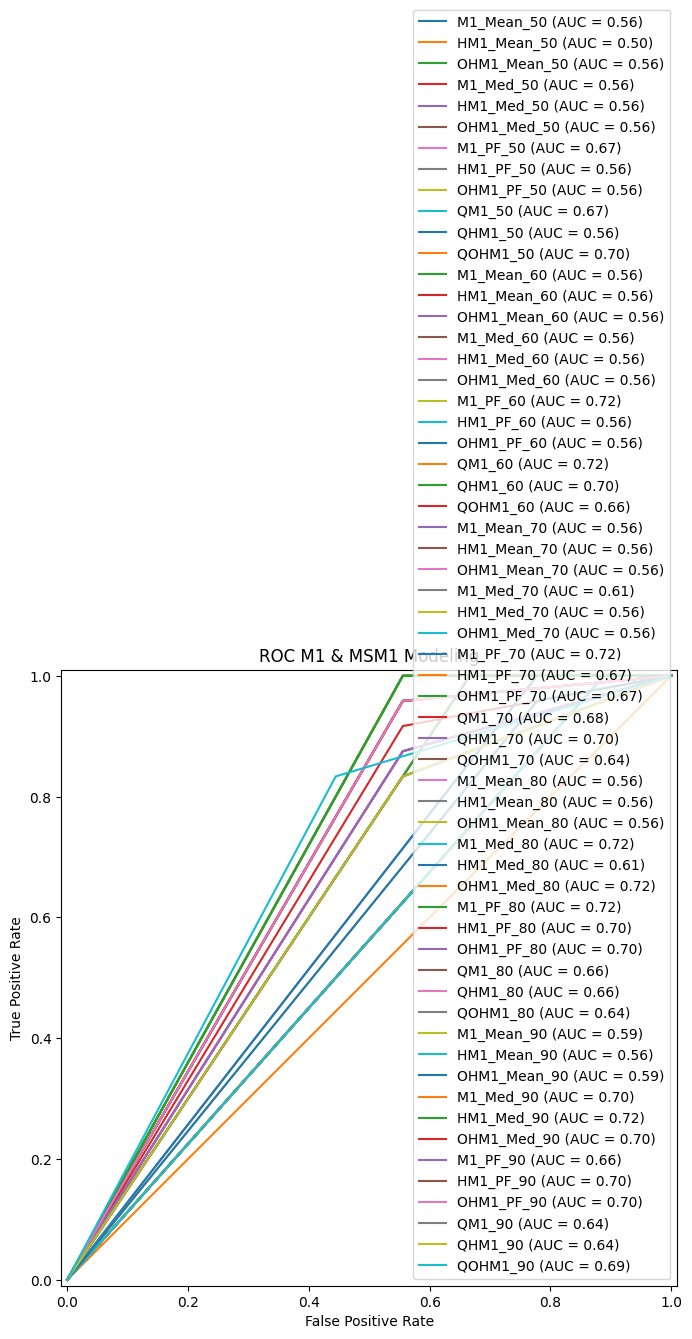

In [19]:
ground_truth_col = 'DF'
roc_results = compute_roc(ROC_df, ground_truth_col, columns_after_df)

# Optional: Plot ROC curves for each column
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
for pred_col in columns_after_df:
    fpr, tpr, _ = roc_curve(ROC_df['DF'], ROC_df[pred_col])
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr), estimator_name=pred_col).plot(ax=plt.gca())

plt.title('ROC M1 & MSM1 Modeling')
plt.legend(loc='lower right')
plt.show()

In [20]:
roc_results

,Prediction Column,TP,FP,TN,FN,Sensitivity,Specificity,Accuracy,Kappa,Threat Score,FPR
0,M1_Mean_50,24,8,1,0,1.000000,0.111111,0.757576,0.153846,0.750000,0.888889
1,HM1_Mean_50,24,9,0,0,1.000000,0.000000,0.727273,0.000000,0.727273,1.000000
2,OHM1_Mean_50,24,8,1,0,1.000000,0.111111,0.757576,0.153846,0.750000,0.888889
3,M1_Med_50,24,8,1,0,1.000000,0.111111,0.757576,0.153846,0.750000,0.888889
4,HM1_Med_50,24,8,1,0,1.000000,0.111111,0.757576,0.153846,0.750000,0.888889
5,OHM1_Med_50,24,8,1,0,1.000000,0.111111,0.757576,0.153846,0.750000,0.888889
6,M1_PF_50,24,6,3,0,1.000000,0.333333,0.818182,0.421053,0.800000,0.666667
7,HM1_PF_50,24,8,1,0,1.000000,0.111111,0.757576,0.153846,0.750000,0.888889
8,OHM1_PF_50,24,8,1,0,1.000000,0.111111,0.757576,0.153846,0.750000,0.888889
9,QM1_50,24,6,3,0,1.000000,0.333333,0.818182,0.421053,0.800000,0.666667


In [21]:
roc_results.to_csv(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MvH_ROC_Results.csv', index=False)

In [23]:
large_basins_df = ROC_df[ROC_df['AREA'] >= 1000000]
small_basins_df = ROC_df[ROC_df['AREA'] <= 1000000]
small_basins_df

,BASIN_ID,AREA,M1P_Mean,M1P_Med,M1P_PF,QM1,HM1P_Mean,HM1P_Med,HM1P_PF,QHM1,...,OHM1_Mean_90,M1_Med_90,HM1_Med_90,OHM1_Med_90,M1_PF_90,HM1_PF_90,OHM1_PF_90,QM1_90,QHM1_90,QOHM1_90
0,12057,321900.000000,0.998743,0.999379,0.999738,0.988967,0.999664,0.999818,0.999915,0.995891,...,1,1,1,1,1,1,1,1,1,1
1,13281,344200.000000,0.910854,0.651211,0.472421,0.419910,0.955901,0.774203,0.602017,0.512938,...,1,0,0,0,0,0,0,0,0,0
2,19777,210200.000000,0.999584,0.999735,0.999809,0.998864,0.999862,0.999924,0.999936,0.999615,...,1,1,1,1,1,1,1,1,1,1
3,20254,126099.999999,0.998125,0.999110,0.999434,0.991657,0.998887,0.999524,0.999720,0.994900,...,1,1,1,1,1,1,1,1,1,1
4,20308,175500.000000,0.999988,0.999998,0.999999,0.999391,0.999993,0.999999,1.000000,0.999449,...,1,1,1,1,1,1,1,1,1,1
5,21634,69500.000000,0.993195,0.994789,0.999134,0.945763,0.993829,0.995601,0.999461,0.941958,...,1,1,1,1,1,1,1,1,1,0
8,17987,168300.000000,0.999938,0.999948,0.999954,0.999890,0.999983,0.999985,0.999985,0.999967,...,1,1,1,1,1,1,1,1,1,1
10,19167,84400.000000,0.999951,0.999967,0.999976,0.999897,0.999974,0.999983,0.999989,0.999924,...,1,1,1,1,1,1,1,1,1,1
11,19381,134200.000000,0.996708,0.996919,0.996911,0.993118,0.998440,0.998747,0.999056,0.996689,...,1,1,1,1,1,1,1,1,1,1
13,19451,453600.000000,0.997394,0.997700,0.998017,0.993517,0.999256,0.999331,0.999397,0.997917,...,1,1,1,1,1,1,1,1,1,1


In [24]:
large_results = compute_roc(large_basins_df, ground_truth_col, columns_after_df)
large_results


,Prediction Column,TP,FP,TN,FN,Sensitivity,Specificity,Accuracy,Kappa,Threat Score,FPR
0,M1_Mean_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0
1,HM1_Mean_50,7,1,0,0,1.0,0.0,0.875,0.0,0.875,1.0
2,OHM1_Mean_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0
3,M1_Med_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0
4,HM1_Med_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0
5,OHM1_Med_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0
6,M1_PF_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0
7,HM1_PF_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0
8,OHM1_PF_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0
9,QM1_50,7,0,1,0,1.0,1.0,1.000,1.0,1.000,0.0


In [25]:
small_results = compute_roc(small_basins_df, ground_truth_col, columns_after_df)
small_results

,Prediction Column,TP,FP,TN,FN,Sensitivity,Specificity,Accuracy,Kappa,Threat Score,FPR
0,M1_Mean_50,17,8,0,0,1.000000,0.000,0.68,0.000000,0.680000,1.000
1,HM1_Mean_50,17,8,0,0,1.000000,0.000,0.68,0.000000,0.680000,1.000
2,OHM1_Mean_50,17,8,0,0,1.000000,0.000,0.68,0.000000,0.680000,1.000
3,M1_Med_50,17,8,0,0,1.000000,0.000,0.68,0.000000,0.680000,1.000
4,HM1_Med_50,17,8,0,0,1.000000,0.000,0.68,0.000000,0.680000,1.000
5,OHM1_Med_50,17,8,0,0,1.000000,0.000,0.68,0.000000,0.680000,1.000
6,M1_PF_50,17,6,2,0,1.000000,0.250,0.76,0.311927,0.739130,0.750
7,HM1_PF_50,17,8,0,0,1.000000,0.000,0.68,0.000000,0.680000,1.000
8,OHM1_PF_50,17,8,0,0,1.000000,0.000,0.68,0.000000,0.680000,1.000
9,QM1_50,17,6,2,0,1.000000,0.250,0.76,0.311927,0.739130,0.750


In [26]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, roc_curve, auc

def compute_roc(df, ground_truth, prediction_col, basin_id_col='BASIN_ID'):
    results = []
    basin_results = []

    for pred_col in prediction_col:
        TP = ((df[ground_truth] == 1) & (df[pred_col] == 1)).sum()
        FP = ((df[ground_truth] == 0) & (df[pred_col] == 1)).sum()
        TN = ((df[ground_truth] == 0) & (df[pred_col] == 0)).sum()
        FN = ((df[ground_truth] == 1) & (df[pred_col] == 0)).sum()

        TPR = TP / (TP + FN) if (TP + FN) != 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) != 0 else 0
        SPC = TN / (TN + FP) if (TN + FP) != 0 else 0
        ACC = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) != 0 else 0
        THT = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0

        kappa_score = cohen_kappa_score(df[ground_truth], df[pred_col])
        fpr, tpr, _ = roc_curve(df[ground_truth], df[pred_col])
        roc_auc = auc(fpr, tpr)

        results.append({
            "Prediction Column": pred_col,
            "TP": TP,
            "FP": FP,
            "TN": TN,
            "FN": FN,
            "Sensitivity": TPR,
            "Specificity": SPC,
            "Accuracy": ACC,
            "Kappa": kappa_score,
            "Threat Score": THT,
            "FPR": FPR,
            "AUC": roc_auc
        })

        temp = df[[basin_id_col, ground_truth, pred_col]].copy()
        temp = temp.rename(columns={
            ground_truth: "Observed",
            pred_col: "Predicted"
        })

        temp["Prediction Column"] = pred_col
        temp["Correct"] = (temp["Observed"] == temp["Predicted"]).astype(int)

        temp["Class"] = "TN"
        temp.loc[(temp["Observed"] == 0) & (temp["Predicted"] == 1), "Class"] = "FP"
        temp.loc[(temp["Observed"] == 1) & (temp["Predicted"] == 0), "Class"] = "FN"
        temp.loc[(temp["Observed"] == 1) & (temp["Predicted"] == 1), "Class"] = "TP"

        basin_results.append(temp)

    summary_df = pd.DataFrame(results)
    basin_df = pd.concat(basin_results, ignore_index=True)

    return summary_df, basin_df

In [30]:
summary_df, basin_df = compute_roc(
    df=ROC_df,
    ground_truth=ground_truth_col,
    prediction_col=columns_after_df,
    basin_id_col='BASIN_ID'
)

In [33]:
basin_df.to_csv(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MvH_Basin_Level_Results.csv', index=False)
